# BNPL Default Risk – Data Exploration & Preparation

## Workflow Overview
This notebook performs exploratory data analysis (EDA) and prepares the dataset for machine learning. The workflow is:

1. **Load raw data** – verify structure and basic statistics.
2. **Quality checks** – examine missing values, duplicates, and garbage (negative/out-of-range values).
3. **Numerical EDA** – visualise distributions and relationships with the target variable.
4. **Categorical EDA** – analyse how categorical features correlate with default risk.
5. **Imputation (for EDA)** – apply KNN imputation to the full dataset to visualise complete data.
6. **Feature engineering** – create Debt-to-Income ratio.
7. **Correlation analysis** – understand feature relationships.
8. **Leakage‑free preparation** – split, impute on train only, scale, and (optionally) save cache.

## Key Decisions & Justifications

### 1. KNN Imputation (k=5, median)
**Why KNN, not mean/median?**  
Mean/median imputation ignores relationships between features. A 22-year-old student and a 55-year-old executive have completely different income distributions. KNN preserves local structure by using similar rows (based on scaled numerics + one‑hot categoricals) to infer missing values.

**Why k=5?**  
Small k preserves local patterns; larger k oversmooths. k=5 is a standard compromise for datasets of this size.

**Why median, not mean?**  
We treat outliers as potential signal (high debtors may default). Mean is sensitive to outliers; median is robust and preserves the central tendency of the nearest neighbours.

**Why impute the full dataset first?**  
For EDA visualisation only – it lets us plot complete distributions and correlations. This imputation is **not** used for modeling; the leakage‑free pipeline imputes only on the training set.

### 2. RobustScaler (not StandardScaler)
**Why not StandardScaler?**  
StandardScaler uses mean and standard deviation, which are pulled by outliers. Since outliers (e.g., extremely high income or debt) may be the most informative for default risk, we use RobustScaler (median + IQR). It preserves the outlier signal while fairly scaling the bulk of the data.

### 3. Debt-to-Income Ratio
**Why engineer this feature?**  
Domain knowledge: a person with $10,000 BNPL debt earning $200,000 is safe; with $25,000 income they are risky. Raw `Debt` and raw `Income` separately are weak signals; the ratio is the true indicator of repayment capacity. This benefits all models (linear, tree, neural) and is added after imputation to avoid using imputed values in the ratio calculation.

### 4. Stratified Train/Test Split
**Why stratified?**  
The target has only 6.8% Medium and 5.2% High risk. A random split could put zero High‑risk cases in the test set, making evaluation unreliable. Stratification ensures the test set mirrors the training distribution exactly.

### Imports and Configuration
Set up the notebook environment. We import utility functions from `src/utils.py` to keep the notebook concise and maintainable.

In [1]:
import sys
sys.path.append('../src')   # so we can import utils
import utils as U
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Load Raw Data
Load the BNPL dataset. The file should be located at `data/BNPL_Financial_Default_Risk_Dataset.csv`.

In [2]:
file_path = "../data/BNPL_Financial_Default_Risk_Dataset.csv"
df_raw = U.load_raw_data(file_path)
print(f"Loaded shape: {df_raw.shape}")

Loaded shape: (10000, 11)


### Define Feature Groups
- **Numerical features**: Age, loan counts, debt amounts, income, credit score.
- **Categorical features**: Employment status, late payment history, shopping category.
These will be treated differently during preprocessing and modeling.

In [3]:
target_col = 'Default_Risk'
id_col = 'Customer_ID'
num_cols = ['Age', 'Total_BNPL_Active_Loans', 'Total_BNPL_Debt_USD',
            'Average_Transaction_Value_USD', 'Income_USD', 'Credit_Score']
cat_cols = ['Employment_Status', 'Late_Payment_History', 'Shopping_Category_Most_Frequent']

### Data Quality Assessment
- **Missing values**: Only Income_USD (305) and Credit_Score (298) are missing – ~3% of rows.
- **Duplicates**: None.
- **Garbage values**: No negative ages, income, or out‑of‑range credit scores.
This confirms the data is clean apart from the two missing columns.

In [4]:
U.quality_check(df_raw, num_cols)

Dataset Overview
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Customer_ID                      10000 non-null  str    
 1   Age                              10000 non-null  int64  
 2   Employment_Status                10000 non-null  str    
 3   Income_USD                       9695 non-null   float64
 4   Credit_Score                     9702 non-null   float64
 5   Total_BNPL_Active_Loans          10000 non-null  int64  
 6   Total_BNPL_Debt_USD              10000 non-null  int64  
 7   Late_Payment_History             10000 non-null  str    
 8   Shopping_Category_Most_Frequent  10000 non-null  str    
 9   Average_Transaction_Value_USD    10000 non-null  int64  
 10  Default_Risk                     10000 non-null  str    
dtypes: float64(2), int64(4), str(5)
memory usage: 859.5 KB

Data Quality Check:

### Numerical Distributions
Histograms reveal skewness and outliers. Note that `Total_BNPL_Active_Loans` is discrete (0–10), so we omit the smooth KDE curve for clarity.

### Numerical Features vs Default Risk
Boxplots show how each numeric feature varies across Low/Medium/High risk. We expect credit score to decrease and debt to increase as risk rises.

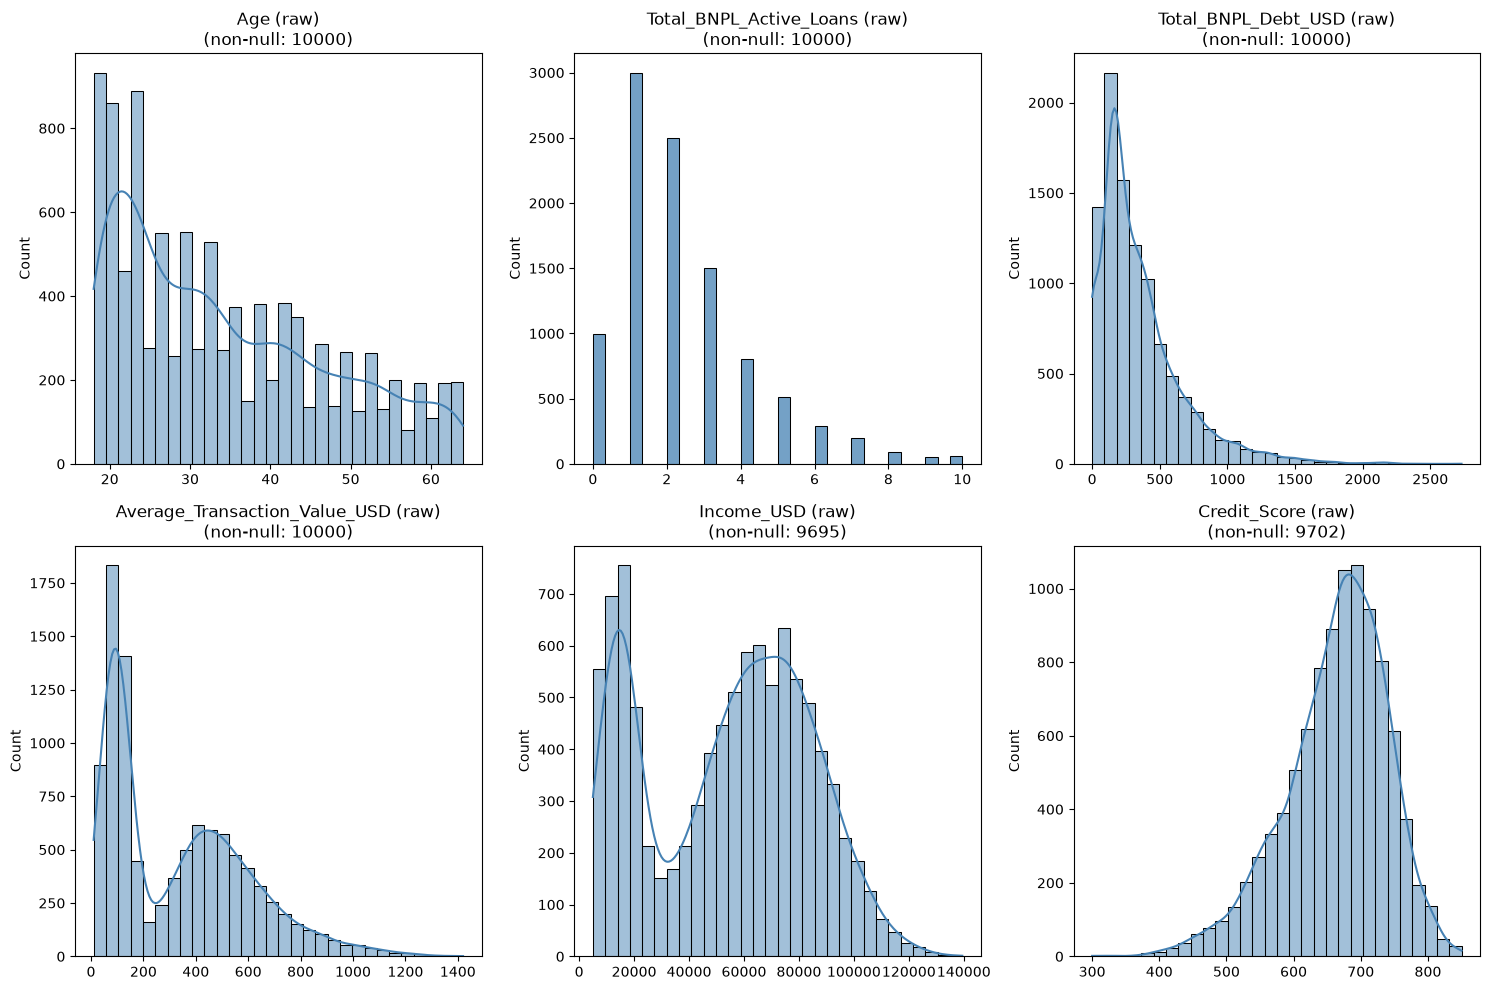

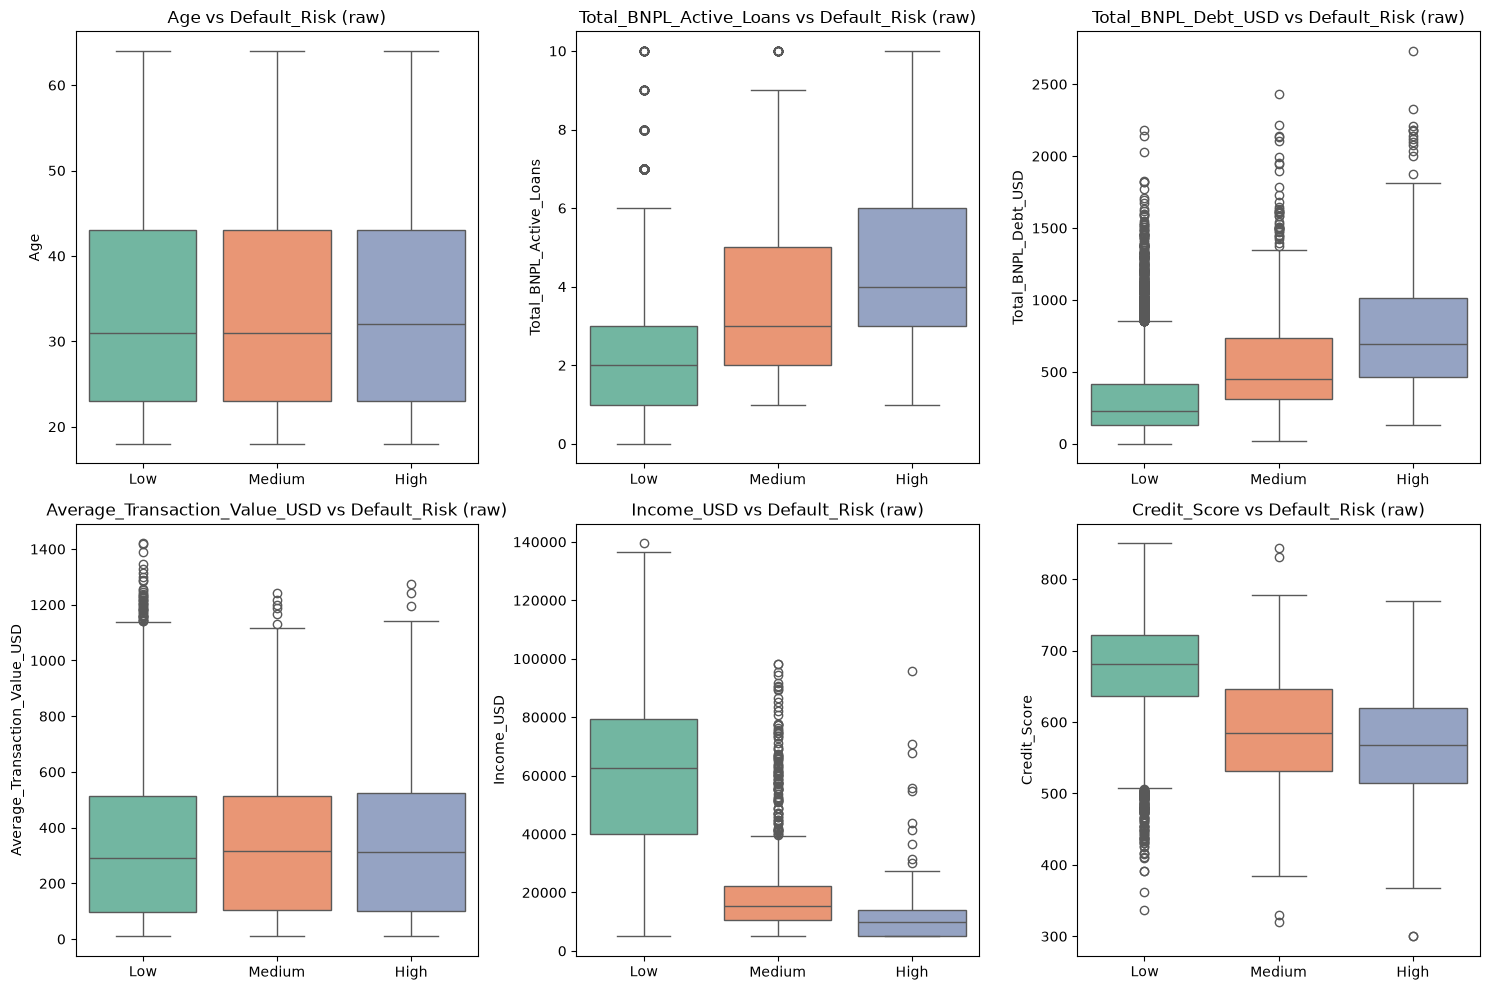

In [5]:
U.plot_histograms(df_raw, num_cols)
plt.show()

U.plot_boxplots(df_raw, num_cols, target_col)
plt.show()

### Categorical Breakdown vs Default Risk
This cross‑tab shows the percentage of each risk category within each categorical group. For example, `Unemployed` customers have 36.8% High risk vs only 0.2% for `Employed`. This validates domain intuition.

In [6]:
U.categorical_crosstab(df_raw, cat_cols, target_col)


Categorical breakdown vs Default_Risk (as %):

--- Employment_Status ---
Default_Risk        Low  Medium  High
Employment_Status                    
Employed           98.3     1.5   0.2
Freelancer         92.1     5.6   2.3
Student            66.4    19.0  14.6
Unemployed         37.4    25.8  36.8

--- Late_Payment_History ---
Default_Risk           Low  Medium  High
Late_Payment_History                    
No                    94.6     3.0   2.4
Yes                   68.1    18.2  13.7

--- Shopping_Category_Most_Frequent ---
Default_Risk                      Low  Medium  High
Shopping_Category_Most_Frequent                    
Electronics                      87.6     7.0   5.3
Fashion                          88.3     6.6   5.1
Groceries/Essentials             89.5     6.4   4.1
Home/Furniture                   88.3     6.5   5.2
Travel                           86.9     7.3   5.8


### KNN Imputation (for EDA only)
We impute missing Income and Credit Score using the full dataset. This is purely for visualisation – the model pipeline will perform imputation without leakage.

In [7]:
df_imputed, _ = U.knn_impute_full(df_raw, num_cols, cat_cols)

Feature matrix shape: (10000, 14)
Missing before: 603 | after: 0


### Statistical Verification of Imputation
The imputed means and medians are very close to the original non‑null values, confirming that KNN preserved the distribution rather than introducing artificial shifts.

In [8]:
U.verify_imputation_stats(df_raw, df_imputed)


Verifying Imputed Data Statistically

--- Income_USD ---
  Original (non-null) Mean: 53981.14 | Median: 58596.00
  Imputed (full) Mean:      54039.79 | Median: 58784.50
  Difference in Mean:       58.65

--- Credit_Score ---
  Original (non-null) Mean: 663.67 | Median: 673.00
  Imputed (full) Mean:      663.59 | Median: 673.00
  Difference in Mean:       -0.08


### Feature Engineering: Debt-to-Income Ratio
Add `Debt_to_Income_Ratio = Total_BNPL_Debt_USD / Income_USD`. This is a critical feature; a high ratio indicates over‑leverage and higher default risk.

In [9]:
df_imputed['Debt_to_Income_Ratio'] = (
    df_imputed['Total_BNPL_Debt_USD'] / df_imputed['Income_USD'].replace(0, np.nan)
)
num_cols_with_ratio = num_cols + ['Debt_to_Income_Ratio']
print("Added Debt_to_Income_Ratio")

Added Debt_to_Income_Ratio


### Visual Check of Imputation
Overlaid histograms show raw (red) vs imputed (blue) distributions. The imputed values blend smoothly into the existing distribution – no unnatural spikes.

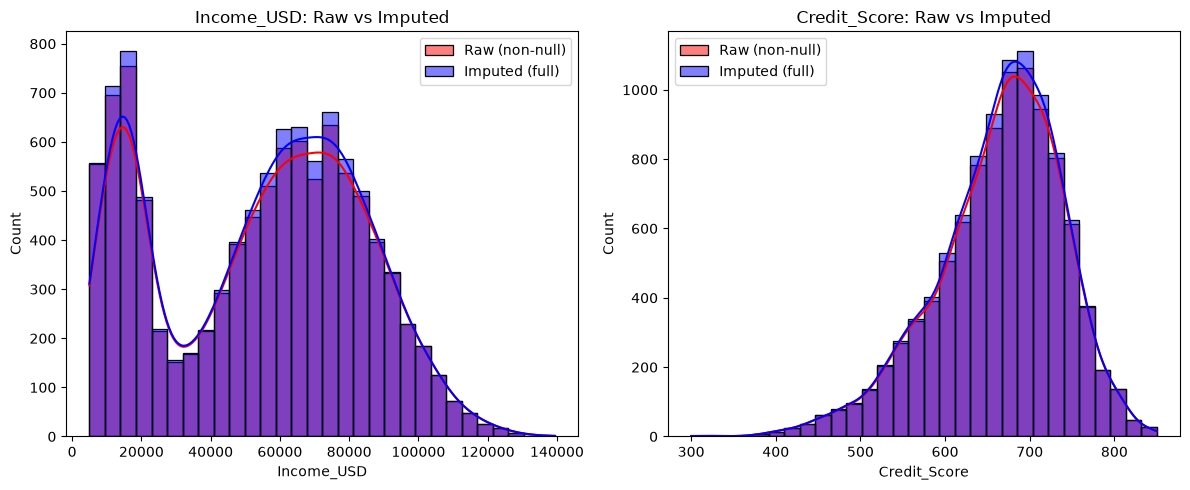

In [10]:
U.plot_imputation_overlay(df_raw, df_imputed, ['Income_USD', 'Credit_Score'])
plt.show()

### Correlation Heatmap
This shows how numeric features relate to each other. A high correlation between `Total_BNPL_Debt_USD` and `Total_BNPL_Active_Loans` is expected; we may consider dropping one or using the ratio instead.

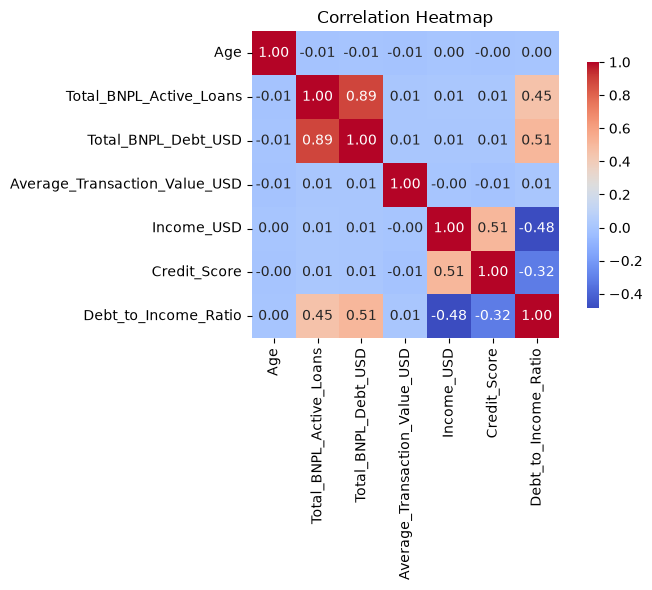

In [11]:
U.plot_correlation_heatmap(df_imputed, num_cols_with_ratio)
plt.show()

### Robust Scaling (EDA Verification)
We apply RobustScaler to the imputed data to verify that median = 0 and IQR = 1. This confirms the scaling logic for the modeling pipeline.

In [12]:
scaler, scaled_df = U.verify_robust_scaler(df_imputed, num_cols_with_ratio, id_col, target_col)

Verification (should have median ≈ 0, IQR ≈ 1):
        Age  Total_BNPL_Active_Loans  Total_BNPL_Debt_USD  \
median  0.0                      0.0                  0.0   
IQR     1.0                      1.0                  1.0   

        Average_Transaction_Value_USD  Income_USD  Credit_Score  \
median                            0.0         0.0           0.0   
IQR                               1.0         1.0           1.0   

        Debt_to_Income_Ratio  
median                   0.0  
IQR                      1.0  


### Leakage‑Free Data Preparation
We perform:
- Stratified split (80/20) preserving target distribution.
- KNN imputation **fitted on train only**.
- Debt-to-Income ratio added **after imputation**.
- RobustScaler **fitted on train only**.
The notebook runs with `save=False` (no cache written) – saving is reserved for the `.py` scripts.

In [13]:
(train_imp, test_imp,
 X_train_scaled, X_test_scaled,
 cat_train, cat_test,
 cat_cardinalities,
 num_cols_with_ratio) = U.prepare_and_save_data(
    df_raw, target_col, id_col, num_cols, cat_cols,
    test_size=0.2, save=False
)

Train shape: (8000, 11), Test shape: (2000, 11)
Data prepared but not saved (save=False).


### Final Verification
Print shapes and target distributions to confirm the split and preparation are correct. The test set mirrors the training proportions exactly.

In [14]:
print("Training target distribution:")
print(pd.Series(train_imp[target_col]).value_counts(normalize=True).round(3))
print("\nTest target distribution:")
print(pd.Series(test_imp[target_col]).value_counts(normalize=True).round(3))

print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print(f"cat_train shape:      {cat_train.shape}")
print(f"cat_test shape:       {cat_test.shape}")
print(f"cat_cardinalities:    {cat_cardinalities}")

Training target distribution:
Default_Risk
Low       0.880
Medium    0.068
High      0.052
Name: proportion, dtype: float64

Test target distribution:
Default_Risk
Low       0.880
Medium    0.068
High      0.052
Name: proportion, dtype: float64

X_train_scaled shape: (8000, 7)
X_test_scaled shape:  (2000, 7)
cat_train shape:      (8000, 3)
cat_test shape:       (2000, 3)
cat_cardinalities:    [4, 2, 5]
